# Clustering Stability Analysis

Assess how stable k-means clustering is when applied to embeddings from different training runs.

**Metrics:**
- Adjusted Rand Index (ARI) between cluster assignments
- Normalized Mutual Information (NMI)
- Per-OA cluster assignment consistency

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from itertools import combinations
from tqdm import tqdm
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Setup complete")

Setup complete


## Configuration

In [2]:
# Paths
output_dir = "../AE_outputs/retraining_stability/"
models_dir = f"{output_dir}/models"

# Parameters from stability experiment
latent_dim = 100
n_runs = 10
n_epochs = 250

# Clustering parameters
n_clusters = 8  # Number of clusters for k-means
kmeans_random_state = 42  # Fixed seed for k-means reproducibility

print(f"Configuration:")
print(f"  Latent dim: {latent_dim}")
print(f"  N runs: {n_runs}")
print(f"  N epochs: {n_epochs}")
print(f"  N clusters: {n_clusters}")

Configuration:
  Latent dim: 100
  N runs: 10
  N epochs: 250
  N clusters: 8


## Load Embeddings

In [3]:
# Load embeddings from the latent CSV files
ae_embeddings_list = []

for run_idx in range(n_runs):
    run_name = f"run_{run_idx}"
    model_nickname = f"stability_{run_name}__ae_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
    latent_csv_path = f"{models_dir}/{model_nickname}__latent.csv"
    
    latent_df = pd.read_csv(latent_csv_path, index_col="OA")
    ae_embeddings_list.append(latent_df.values)
    print(f"[{run_name}] Loaded embeddings: {latent_df.shape}")

# Get OA IDs from first file
oa_ids = pd.read_csv(f"{models_dir}/stability_run_0__ae_{latent_dim}d_run_0_{n_epochs}ep_v1__latent.csv", index_col="OA").index.values

print(f"\nLoaded {len(ae_embeddings_list)} embeddings")
print(f"Each embedding shape: {ae_embeddings_list[0].shape}")
print(f"Total OAs: {len(oa_ids)}")

[run_0] Loaded embeddings: (188880, 100)
[run_1] Loaded embeddings: (188880, 100)
[run_2] Loaded embeddings: (188880, 100)
[run_3] Loaded embeddings: (188880, 100)
[run_4] Loaded embeddings: (188880, 100)
[run_5] Loaded embeddings: (188880, 100)
[run_6] Loaded embeddings: (188880, 100)
[run_7] Loaded embeddings: (188880, 100)
[run_8] Loaded embeddings: (188880, 100)
[run_9] Loaded embeddings: (188880, 100)

Loaded 10 embeddings
Each embedding shape: (188880, 100)
Total OAs: 188880


## Run K-Means on Each Embedding

In [9]:
print("=" * 80)
print(f"Running K-Means (k={n_clusters}) on each embedding")
print("=" * 80)

cluster_labels_list = []

for run_idx, embeddings in enumerate(tqdm(ae_embeddings_list, desc="Clustering")):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=kmeans_random_state,
        n_init=100
    )
    labels = kmeans.fit_predict(embeddings)
    cluster_labels_list.append(labels)
    print(f"[run_{run_idx}] Cluster sizes: {np.bincount(labels)}")

print(f"\nClustered {n_runs} embeddings")

Running K-Means (k=8) on each embedding


Clustering:  10%|█         | 1/10 [01:48<16:18, 108.73s/it]

[run_0] Cluster sizes: [14495 30321 20461 13954 25905 35221 32747 15776]


Clustering:  20%|██        | 2/10 [03:35<14:18, 107.37s/it]

[run_1] Cluster sizes: [30818 15551 37373 24881 20510 13126 32859 13762]


...

[run_7] Cluster sizes: [22406 32213 16198 27742 14364 14013 27852 34092]


Clustering:  90%|█████████ | 9/10 [15:17<01:40, 100.53s/it]

[run_8] Cluster sizes: [15143 24971 33192 16173 36138 19526 13142 30595]


Clustering: 100%|██████████| 10/10 [16:41<00:00, 100.16s/it]

[run_9] Cluster sizes: [32857 30042 31759 15873 27809 14777 21143 14620]

Clustered 10 embeddings


## Compute Pairwise Clustering Similarity

In [11]:
print("=" * 80)
print("Computing pairwise clustering similarity")
print("=" * 80)

# Compute ARI and NMI for all pairs
ari_scores = []
nmi_scores = []
ari_matrix = np.ones((n_runs, n_runs))
nmi_matrix = np.ones((n_runs, n_runs))

for i, j in combinations(range(n_runs), 2):
    ari = adjusted_rand_score(cluster_labels_list[i], cluster_labels_list[j])
    nmi = normalized_mutual_info_score(cluster_labels_list[i], cluster_labels_list[j])
    
    ari_scores.append(ari)
    nmi_scores.append(nmi)
    
    ari_matrix[i, j] = ari
    ari_matrix[j, i] = ari
    nmi_matrix[i, j] = nmi
    nmi_matrix[j, i] = nmi

ari_scores = np.array(ari_scores)
nmi_scores = np.array(nmi_scores)

print(f"\nAdjusted Rand Index (ARI):")
print(f"  Mean: {ari_scores.mean():.4f}")
print(f"  Std:  {ari_scores.std():.4f}")
print(f"  Min:  {ari_scores.min():.4f}")
print(f"  Max:  {ari_scores.max():.4f}")

print(f"\nNormalized Mutual Information (NMI):")
print(f"  Mean: {nmi_scores.mean():.4f}")
print(f"  Std:  {nmi_scores.std():.4f}")
print(f"  Min:  {nmi_scores.min():.4f}")
print(f"  Max:  {nmi_scores.max():.4f}")

# Interpretation
print(f"\nInterpretation:")
if ari_scores.mean() > 0.9:
    print(f"  EXCELLENT clustering stability (ARI > 0.9)")
elif ari_scores.mean() > 0.7:
    print(f"  GOOD clustering stability (ARI > 0.7)")
elif ari_scores.mean() > 0.5:
    print(f"  MODERATE clustering stability (ARI > 0.5)")
else:
    print(f"  POOR clustering stability (ARI < 0.5)")

Computing pairwise clustering similarity

Adjusted Rand Index (ARI):
  Mean: 0.8138
  Std:  0.0841
  Min:  0.5978
  Max:  0.8958

Normalized Mutual Information (NMI):
  Mean: 0.8280
  Std:  0.0486
  Min:  0.7051
  Max:  0.8819

Interpretation:
  GOOD clustering stability (ARI > 0.7)


## Per-OA Cluster Consistency

In [12]:
# Compute per-OA consistency: what fraction of runs assign each OA to the same cluster?
# We use the mode cluster and compute what % of runs match the mode

from scipy.stats import mode

# Stack labels: (n_runs, n_OAs)
labels_array = np.stack(cluster_labels_list, axis=0)

# For each OA, find the mode cluster and count how many runs match it
per_oa_consistency = []
for oa_idx in range(len(oa_ids)):
    oa_labels = labels_array[:, oa_idx]
    mode_result = mode(oa_labels, keepdims=False)
    mode_label = mode_result.mode
    mode_count = mode_result.count
    consistency = mode_count / n_runs
    per_oa_consistency.append(consistency)

per_oa_consistency = np.array(per_oa_consistency)

print("=" * 80)
print("Per-OA Cluster Consistency")
print("=" * 80)

print(f"\nConsistency = fraction of runs assigning OA to its most common cluster")
print(f"  Mean: {per_oa_consistency.mean():.4f}")
print(f"  Median: {np.median(per_oa_consistency):.4f}")
print(f"  Min: {per_oa_consistency.min():.4f}")
print(f"  Max: {per_oa_consistency.max():.4f}")

# Distribution of consistency
print(f"\nDistribution:")
print(f"  100% consistent (all runs agree): {(per_oa_consistency == 1.0).sum()} OAs ({(per_oa_consistency == 1.0).mean()*100:.1f}%)")
print(f"  >= 90% consistent: {(per_oa_consistency >= 0.9).sum()} OAs ({(per_oa_consistency >= 0.9).mean()*100:.1f}%)")
print(f"  >= 80% consistent: {(per_oa_consistency >= 0.8).sum()} OAs ({(per_oa_consistency >= 0.8).mean()*100:.1f}%)")
print(f"  < 50% consistent: {(per_oa_consistency < 0.5).sum()} OAs ({(per_oa_consistency < 0.5).mean()*100:.1f}%)")

Per-OA Cluster Consistency

Consistency = fraction of runs assigning OA to its most common cluster
  Mean: 0.2737
  Median: 0.3000
  Min: 0.2000
  Max: 0.5000

Distribution:
  100% consistent (all runs agree): 0 OAs (0.0%)
  >= 90% consistent: 0 OAs (0.0%)
  >= 80% consistent: 0 OAs (0.0%)
  < 50% consistent: 188503 OAs (99.8%)


## Visualizations

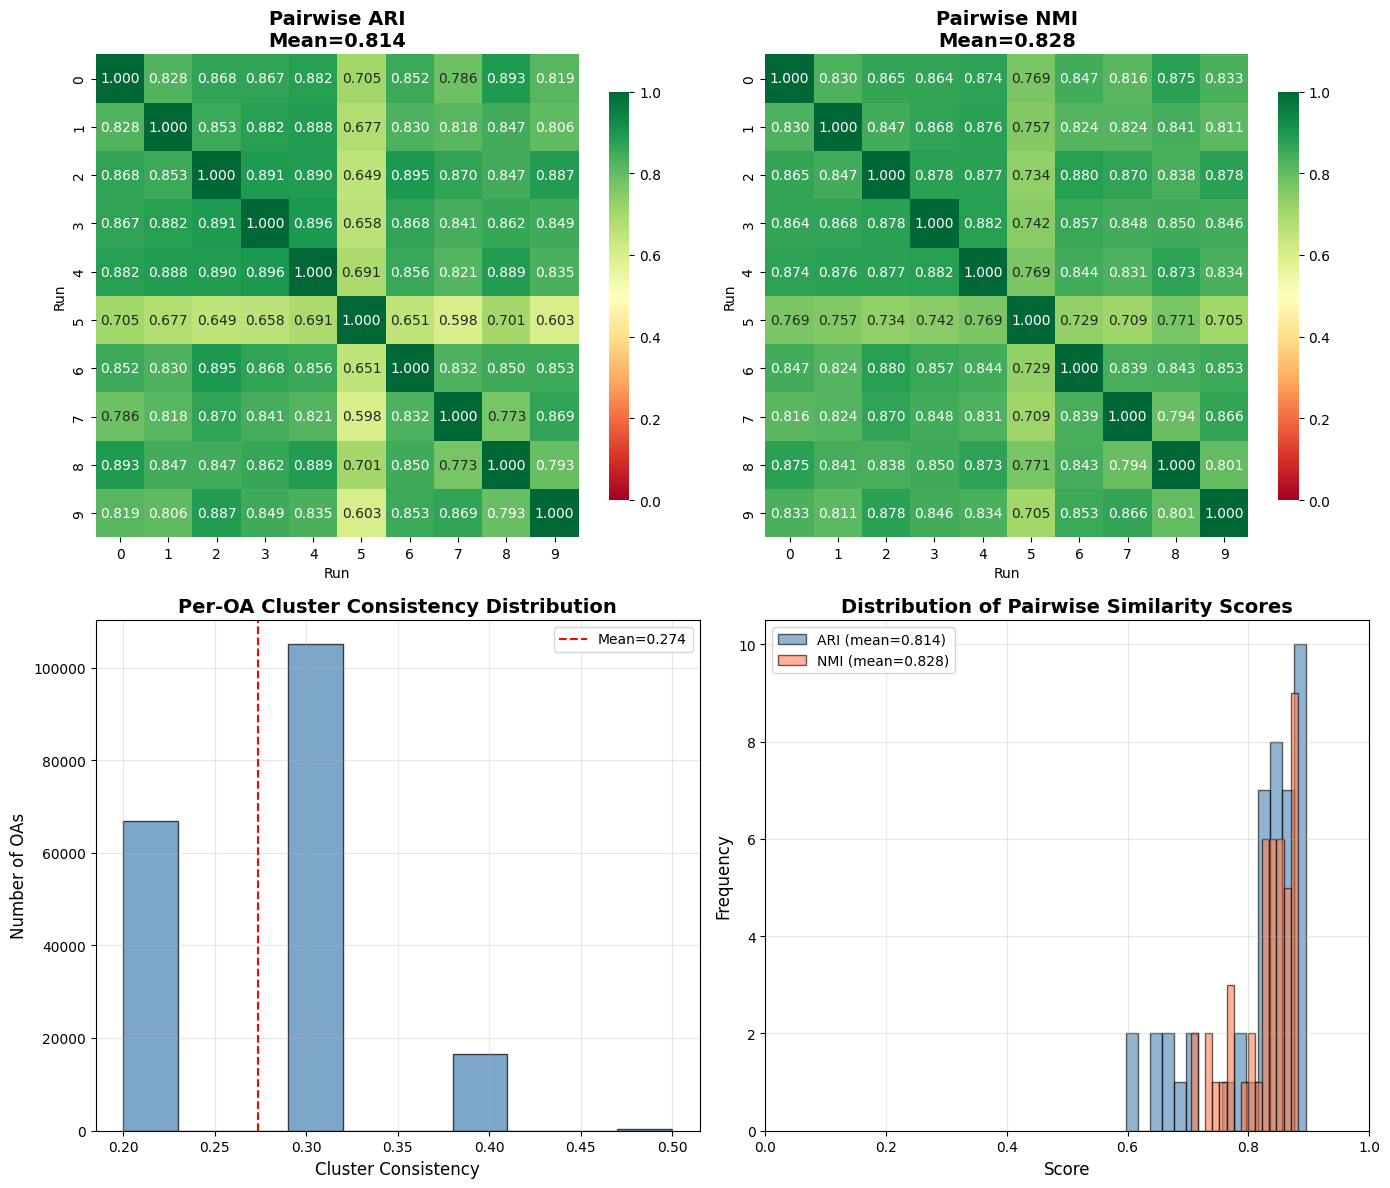

Plots saved to ../AE_outputs/retraining_stability//clustering_stability.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ARI heatmap
sns.heatmap(ari_matrix, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[0, 0], square=True, cbar_kws={'shrink': 0.8})
axes[0, 0].set_title(f'Pairwise ARI\nMean={ari_scores.mean():.3f}', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Run')
axes[0, 0].set_ylabel('Run')

# 2. NMI heatmap
sns.heatmap(nmi_matrix, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[0, 1], square=True, cbar_kws={'shrink': 0.8})
axes[0, 1].set_title(f'Pairwise NMI\nMean={nmi_scores.mean():.3f}', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Run')
axes[0, 1].set_ylabel('Run')

# 3. Distribution of per-OA consistency
axes[1, 0].hist(per_oa_consistency, bins=n_runs, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(per_oa_consistency.mean(), color='red', linestyle='--', 
                   label=f'Mean={per_oa_consistency.mean():.3f}')
axes[1, 0].set_xlabel('Cluster Consistency', fontsize=12)
axes[1, 0].set_ylabel('Number of OAs', fontsize=12)
axes[1, 0].set_title('Per-OA Cluster Consistency Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ARI and NMI distributions
axes[1, 1].hist(ari_scores, bins=15, alpha=0.6, color='steelblue', 
                label=f'ARI (mean={ari_scores.mean():.3f})', edgecolor='black')
axes[1, 1].hist(nmi_scores, bins=15, alpha=0.6, color='coral', 
                label=f'NMI (mean={nmi_scores.mean():.3f})', edgecolor='black')
axes[1, 1].set_xlabel('Score', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of Pairwise Similarity Scores', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig(f"{output_dir}/clustering_stability.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to {output_dir}/clustering_stability.png")

## Summary

In [8]:
print("=" * 80)
print("CLUSTERING STABILITY SUMMARY")
print("=" * 80)

print(f"\nExperiment Setup:")
print(f"  Embeddings: {n_runs} AE training runs")
print(f"  Embedding dim: {latent_dim}D")
print(f"  K-means clusters: {n_clusters}")
print(f"  Total OAs: {len(oa_ids)}")

print(f"\nClustering Similarity (between runs):")
print(f"  Mean ARI: {ari_scores.mean():.4f}")
print(f"  Mean NMI: {nmi_scores.mean():.4f}")

print(f"\nPer-OA Consistency:")
print(f"  Mean: {per_oa_consistency.mean():.4f}")
print(f"  OAs with 100% agreement: {(per_oa_consistency == 1.0).mean()*100:.1f}%")
print(f"  OAs with >= 80% agreement: {(per_oa_consistency >= 0.8).mean()*100:.1f}%")

print(f"\nConclusion:")
if ari_scores.mean() > 0.9:
    print(f"  Clustering is HIGHLY STABLE across retraining runs.")
    print(f"  Researchers will get consistent cluster assignments.")
elif ari_scores.mean() > 0.7:
    print(f"  Clustering is REASONABLY STABLE across retraining runs.")
else:
    print(f"  Clustering shows VARIABILITY across retraining runs.")
    print(f"  Consider using ensemble methods or fixing random seeds.")

print("=" * 80)

CLUSTERING STABILITY SUMMARY

Experiment Setup:
  Embeddings: 10 AE training runs
  Embedding dim: 100D
  K-means clusters: 8
  Total OAs: 188880

Clustering Similarity (between runs):
  Mean ARI: 0.8154
  Mean NMI: 0.8291

Per-OA Consistency:
  Mean: 0.3006
  OAs with 100% agreement: 0.0%
  OAs with >= 80% agreement: 0.0%

Conclusion:
  Clustering is REASONABLY STABLE across retraining runs.
